# Machine Learning

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

df = pd.read_csv('../data/featured_churn.csv')
print("Shape:", df.shape)
print("Churn balance:", df['Churn'].value_counts().to_dict())

Shape: (7032, 23)
Churn balance: {0: 5163, 1: 1869}


In [7]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Train churn: {y_train.mean()*100:.1f}%")
print(f"Test churn : {y_test.mean()*100:.1f}%")

Train size : (5625, 22)
Test size  : (1407, 22)
Train churn: 26.6%
Test churn : 26.6%


In [8]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE : {0: 4130, 1: 4130}


In [9]:
scale_cols = ['tenure', 'MonthlyCharges', 'ChargesPerTenure']
# TotalCharges was dropped in feature engineering

scaler = StandardScaler()

# Fit on training only — transform both
cols_in_df = [c for c in scale_cols if c in X_train_sm.columns]

X_train_sm[cols_in_df] = scaler.fit_transform(X_train_sm[cols_in_df])
X_test[cols_in_df]     = scaler.transform(X_test[cols_in_df])

# Save scaler for deployment
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(cols_in_df, '../models/scale_cols.pkl')
print("Scaler saved.")
print("Scaled columns:", cols_in_df)

Scaler saved.
Scaled columns: ['tenure', 'MonthlyCharges', 'ChargesPerTenure']


In [10]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]

    results = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'ROC_AUC'  : roc_auc_score(y_te, y_prob)
    }

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))

    return results, model, y_prob

In [11]:
# Purpose    : Baseline linear model, interpretable coefficients
# Advantages : Fast, interpretable, works well on linearly separable data
# Limitations: Assumes linearity, struggles with complex interactions

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)

lr_results, lr_model, lr_probs = evaluate_model(
    'Logistic Regression', lr,
    X_train_sm, y_train_sm,
    X_test, y_test
)


  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.89      0.73      0.81      1033
     Churned       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [12]:
# Purpose    : Rule-based, human-readable splits
# Advantages : Interpretable, no scaling needed, handles nonlinearity
# Limitations: Prone to overfitting, unstable

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt_results, dt_model, dt_probs = evaluate_model(
    'Decision Tree', dt,
    X_train_sm, y_train_sm,
    X_test, y_test
)


  Decision Tree
              precision    recall  f1-score   support

    Retained       0.88      0.74      0.80      1033
     Churned       0.50      0.73      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.73      0.75      1407



In [13]:
# Purpose    : Ensemble of trees, reduces overfitting via bagging
# Advantages : Robust, handles nonlinearity, built-in feature importance
# Limitations: Slower, less interpretable than single tree

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_results, rf_model, rf_probs = evaluate_model(
    'Random Forest', rf,
    X_train_sm, y_train_sm,
    X_test, y_test
)


  Random Forest
              precision    recall  f1-score   support

    Retained       0.90      0.74      0.81      1033
     Churned       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [14]:
# Purpose    : Gradient boosting — best performance on tabular data
# Advantages : Handles imbalance, regularization, high accuracy
# Limitations: More hyperparameters, less interpretable natively

# Compute scale_pos_weight for imbalanced data
neg = (y_train_sm == 0).sum()
pos = (y_train_sm == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=neg/pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_results, xgb_model, xgb_probs = evaluate_model(
    'XGBoost', xgb,
    X_train_sm, y_train_sm,
    X_test, y_test
)


  XGBoost
              precision    recall  f1-score   support

    Retained       0.88      0.76      0.81      1033
     Churned       0.52      0.71      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



In [15]:
all_results = pd.DataFrame([lr_results, dt_results, rf_results, xgb_results])
all_results = all_results.set_index('Model')
all_results = all_results.round(4)

print("\n=== MODEL COMPARISON ===")
print(all_results.to_string())

# Highlight best per metric
print("\n=== BEST PER METRIC ===")
for col in all_results.columns:
    best = all_results[col].idxmax()
    print(f"{col:<12}: {best} ({all_results.loc[best, col]:.4f})")


=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall      F1  ROC_AUC
Model                                                            
Logistic Regression    0.7406     0.5081  0.7567  0.6079   0.8241
Decision Tree          0.7349     0.5009  0.7326  0.5950   0.8081
Random Forest          0.7498     0.5200  0.7647  0.6190   0.8305
XGBoost                0.7463     0.5166  0.7059  0.5966   0.8206

=== BEST PER METRIC ===
Accuracy    : Random Forest (0.7498)
Precision   : Random Forest (0.5200)
Recall      : Random Forest (0.7647)
F1          : Random Forest (0.6190)
ROC_AUC     : Random Forest (0.8305)


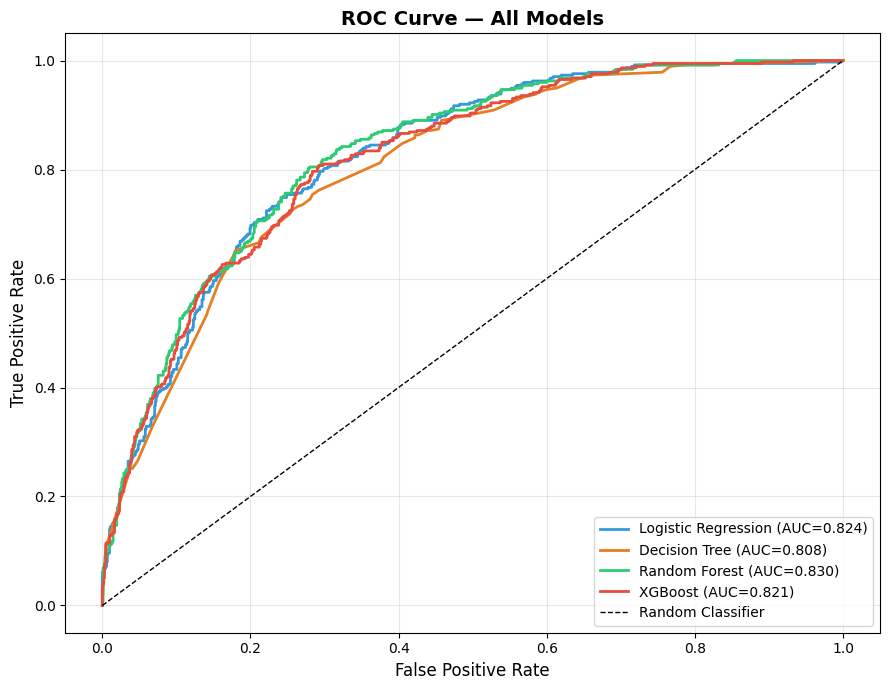

In [16]:
models_info = [
    ('Logistic Regression', lr_probs),
    ('Decision Tree',       dt_probs),
    ('Random Forest',       rf_probs),
    ('XGBoost',             xgb_probs),
]

plt.figure(figsize=(9, 7))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
for (name, probs), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/10_roc_curves.png', dpi=150)
plt.show()

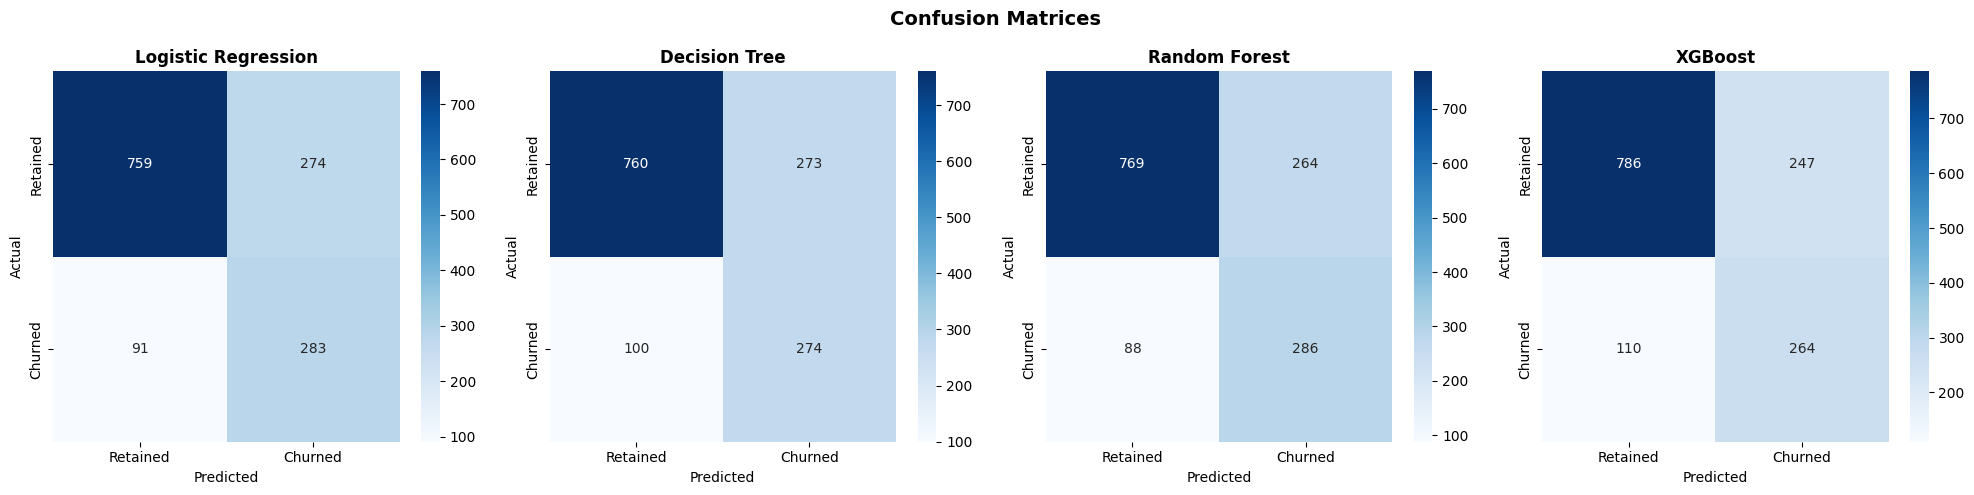

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_cms = [
    ('Logistic Regression', lr_model),
    ('Decision Tree',       dt_model),
    ('Random Forest',       rf_model),
    ('XGBoost',             xgb_model),
]

for ax, (name, model) in zip(axes, models_cms):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/11_confusion_matrices.png', dpi=150)
plt.show()

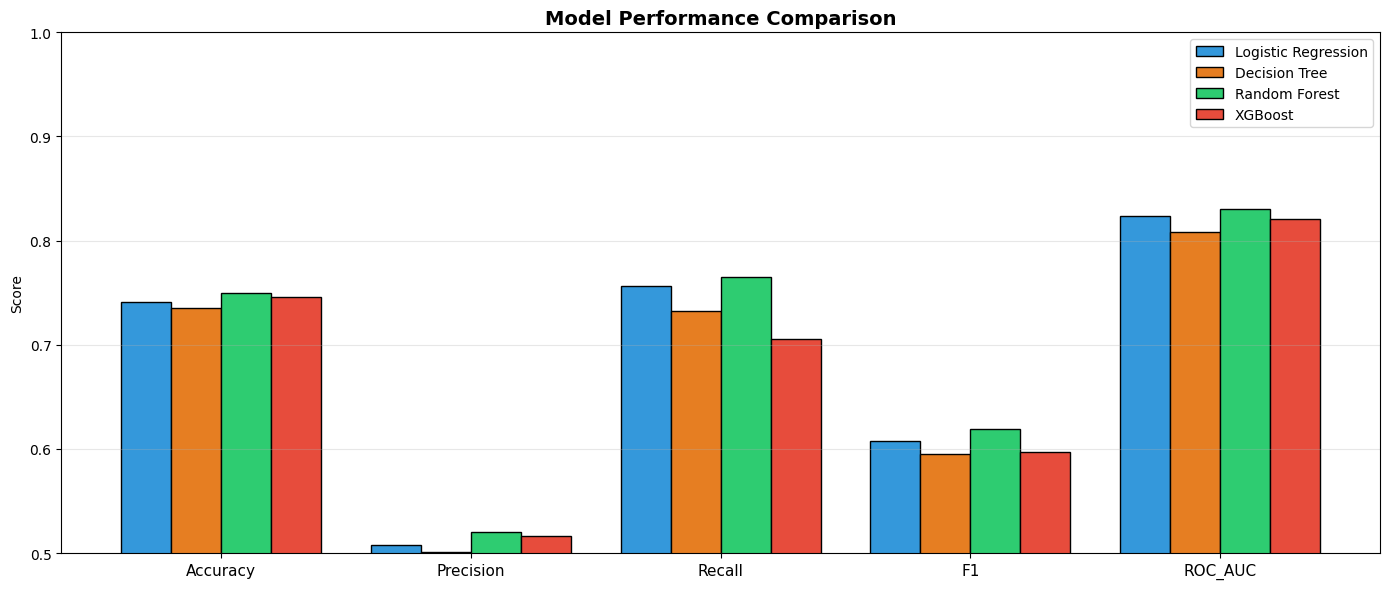

In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, color) in enumerate(zip(all_results.index, colors)):
    vals = all_results.loc[model_name, metrics].values
    ax.bar(x + i*width, vals, width, label=model_name, color=color, edgecolor='black')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/12_model_comparison.png', dpi=150)
plt.show()

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': lr_model,
    'Decision Tree'      : dt_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}

print("=== 5-FOLD CROSS VALIDATION (ROC-AUC) ===")
cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25}: {scores.mean():.4f} ± {scores.std():.4f}")

=== 5-FOLD CROSS VALIDATION (ROC-AUC) ===
Logistic Regression      : 0.8686 ± 0.0041
Decision Tree            : 0.8561 ± 0.0054
Random Forest            : 0.8846 ± 0.0038
XGBoost                  : 0.8971 ± 0.0020


In [20]:
joblib.dump(lr_model,  '../models/logistic_regression.pkl')
joblib.dump(dt_model,  '../models/decision_tree.pkl')
joblib.dump(rf_model,  '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')

# Save feature names for inference pipeline
feature_names = X_train_sm.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("All models saved to models/")
print("Features saved:", len(feature_names))

All models saved to models/
Features saved: 22


In [21]:
all_results.to_csv('../outputs/model_comparison.csv')
print("Results saved → outputs/model_comparison.csv")
print("\nFinal Comparison:")
print(all_results)

Results saved → outputs/model_comparison.csv

Final Comparison:
                     Accuracy  Precision  Recall      F1  ROC_AUC
Model                                                            
Logistic Regression    0.7406     0.5081  0.7567  0.6079   0.8241
Decision Tree          0.7349     0.5009  0.7326  0.5950   0.8081
Random Forest          0.7498     0.5200  0.7647  0.6190   0.8305
XGBoost                0.7463     0.5166  0.7059  0.5966   0.8206
